# Amazon Co-Purchase Network Analysis

## Project Overview

This notebook analyzes the **Amazon product co-purchasing network** from the [SNAP Amazon Metadata dataset](https://snap.stanford.edu/data/amazon-meta.html).

**Core Research Questions:**
1. Do products cluster within their own category, or are co-purchases mostly cross-category?
2. Which categories act as "bridges" connecting different product types?
3. What does the degree distribution reveal about this network's structure?
4. Can we detect meaningful communities at the category level?

**Dataset:** ~548,000 Amazon products with metadata (title, group, sales rank, reviews, categories, co-purchase links)

---

## 1. Environment Setup & Imports

In [43]:
import pandas as pd
import numpy as np
import re
import os
import warnings
import itertools
from collections import Counter, defaultdict

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')
print(f'NetworkX version: {nx.__version__}')
print(f'Pandas version: {pd.__version__}')

All libraries loaded successfully.
NetworkX version: 3.6.1
Pandas version: 3.0.2


## 2. Data Parsing

The Amazon metadata file uses a custom multi-line text format. Each product block starts with `Id:` and contains fields like `ASIN`, `title`, `group`, `salesrank`, `similar` (co-purchased ASINs), `categories`, and `reviews`.

In [44]:
def parse_amazon_metadata(file_path, limit=None):
    """
    Parse the SNAP Amazon metadata file into a pandas DataFrame.
    
    Parameters
    ----------
    file_path : str
        Path to amazon-meta.txt
    limit : int or None
        Maximum number of products to parse. None = parse all.
    
    Returns
    -------
    pd.DataFrame
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f'Data file not found: {file_path}')

    products = []
    current = {}

    print(f'Parsing: {file_path}')
    print('This may take a minute for the full dataset...')

    import gzip
    open_fn = gzip.open if str(file_path).endswith('.gz') else open
    with open_fn(file_path, 'rt', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()

            if line.startswith('Id:'):
                # Save previous product if valid
                if current.get('ASIN'):
                    products.append(current)
                    if limit and len(products) >= limit:
                        break
                current = {
                    'Id': line.split(':', 1)[1].strip(),
                    'categories': [],
                    'similar': []
                }

            elif line.startswith('ASIN:'):
                current['ASIN'] = line.split(':', 1)[1].strip()

            elif line.startswith('title:'):
                current['title'] = line[6:].strip()

            elif line.startswith('group:'):
                current['group'] = line[6:].strip()

            elif line.startswith('salesrank:'):
                try:
                    current['salesrank'] = int(line[10:].strip())
                except ValueError:
                    current['salesrank'] = np.nan

            elif line.startswith('similar:'):
                parts = line.split()
                # Format: "similar: N ASIN1 ASIN2 ..."
                if len(parts) > 2:
                    current['similar'] = parts[2:]

            elif line.startswith('|'):
                current['categories'].append(line)

            elif line.startswith('reviews:'):
                total_m = re.search(r'total:\s*(\d+)', line)
                avg_m   = re.search(r'avg rating:\s*([\d.]+)', line)
                current['reviews_total'] = int(total_m.group(1)) if total_m else 0
                current['avg_rating']    = float(avg_m.group(1)) if avg_m else np.nan

        # Capture last product
        if current.get('ASIN'):
            products.append(current)

    df = pd.DataFrame(products)
    print(f'Done. Total products parsed: {len(df):,}')
    return df


DATA_PATH = 'amazon-meta.txt.gz'
df_raw = parse_amazon_metadata(DATA_PATH)

Parsing: amazon-meta.txt.gz
This may take a minute for the full dataset...
Done. Total products parsed: 548,552


## 3. Basic Data Exploration

In [45]:
print('=== DATAFRAME OVERVIEW ===')
print(f'Shape: {df_raw.shape}')
print()
print('--- Column Types ---')
print(df_raw.dtypes)
print()
print('--- Missing Values ---')
print(df_raw.isnull().sum())
print()
print('--- Sample Row ---')
print(df_raw.iloc[0].to_dict())

=== DATAFRAME OVERVIEW ===
Shape: (548552, 9)

--- Column Types ---
Id                   str
categories        object
similar           object
ASIN                 str
title                str
group                str
salesrank        float64
reviews_total    float64
avg_rating       float64
dtype: object

--- Missing Values ---
Id                  0
categories          0
similar             0
ASIN                0
title            5868
group            5868
salesrank        5868
reviews_total    5868
avg_rating       5868
dtype: int64

--- Sample Row ---
{'Id': '0', 'categories': [], 'similar': [], 'ASIN': '0771044445', 'title': nan, 'group': nan, 'salesrank': nan, 'reviews_total': nan, 'avg_rating': nan}


In [46]:
# Derived columns
df_raw['similar_count'] = df_raw['similar'].apply(len)
df_raw['cat_path_count'] = df_raw['categories'].apply(len)

print('=== KEY STATISTICS ===')
print(f"Total products:                {len(df_raw):,}")
print(f"Products with co-purchase links: {(df_raw['similar_count'] > 0).sum():,} ({(df_raw['similar_count'] > 0).mean():.1%})")
print(f"Products with categories:       {(df_raw['cat_path_count'] > 0).sum():,} ({(df_raw['cat_path_count'] > 0).mean():.1%})")
print(f"Products with reviews:          {(df_raw['reviews_total'] > 0).sum():,}")
print(f"Avg co-purchase links per product: {df_raw['similar_count'].mean():.2f}")
print(f"Max co-purchase links:          {df_raw['similar_count'].max()}")

if 'group' in df_raw.columns:
    print(f"\nProduct groups:")
    print(df_raw['group'].value_counts().to_string())

=== KEY STATISTICS ===
Total products:                548,552
Products with co-purchase links: 379,093 (69.1%)
Products with categories:       519,781 (94.8%)
Products with reviews:          402,735
Avg co-purchase links per product: 3.26
Max co-purchase links:          5

Product groups:
group
Book            393561
Music           103144
Video            26131
DVD              19828
Toy                  8
Software             5
CE                   4
Video Games          1
Baby Product         1
Sports               1


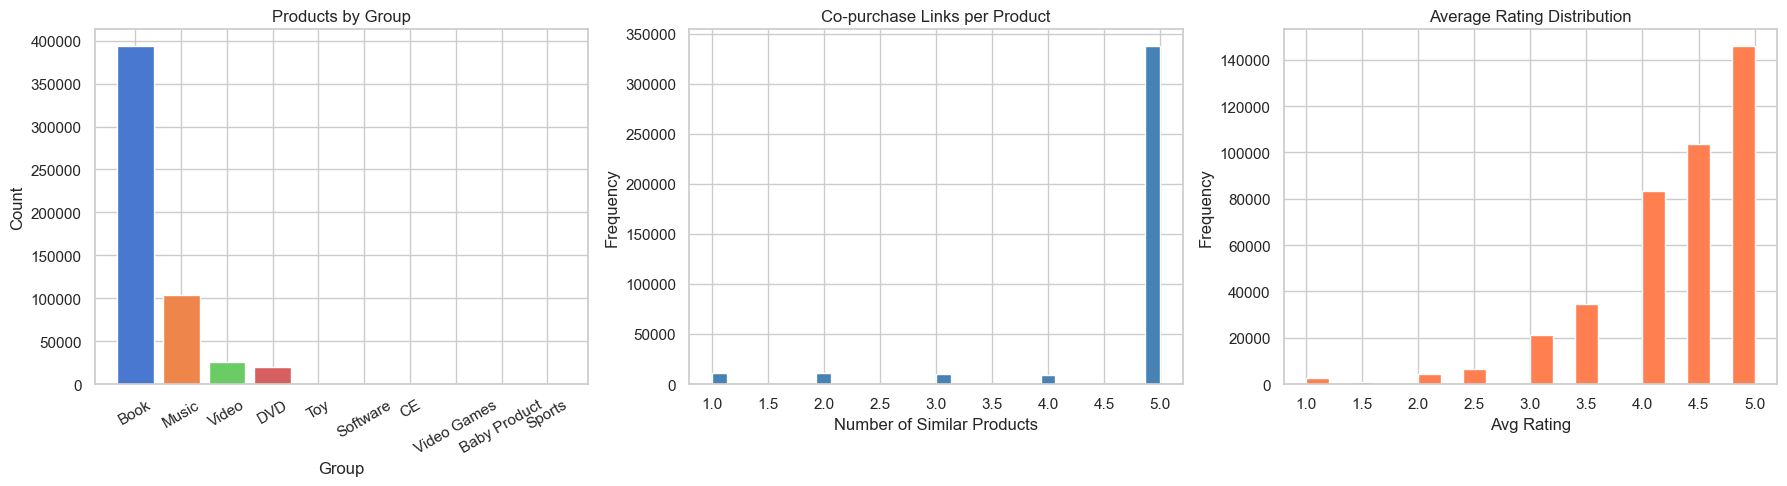

Figure saved: fig1_basic_stats.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Product group distribution
if 'group' in df_raw.columns:
    group_counts = df_raw['group'].value_counts()
    axes[0].bar(group_counts.index, group_counts.values, color=sns.color_palette('muted', len(group_counts)))
    axes[0].set_title('Products by Group')
    axes[0].set_xlabel('Group')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)

# Similar count distribution
axes[1].hist(df_raw['similar_count'][df_raw['similar_count'] > 0], bins=30, color='steelblue', edgecolor='white')
axes[1].set_title('Co-purchase Links per Product')
axes[1].set_xlabel('Number of Similar Products')
axes[1].set_ylabel('Frequency')

# Avg rating distribution
ratings = df_raw['avg_rating'].dropna()
ratings = ratings[ratings > 0]
axes[2].hist(ratings, bins=20, color='coral', edgecolor='white')
axes[2].set_title('Average Rating Distribution')
axes[2].set_xlabel('Avg Rating')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig1_basic_stats.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig1_basic_stats.png')

## 4. Category Extraction & Cleaning

The category field looks like:
```
|Books[283155]|Subjects[1000]|Literature & Fiction[17]|...
```
We extract the **main category** (the first meaningful level after 'Subjects' or 'Books').

In [48]:
def clean_cat_name(name):
    """Remove numeric IDs like [283155] from category names."""
    return re.sub(r'\[\d+\]', '', name).strip()


def extract_main_category(paths):
    """
    Extract the primary category from a list of category path strings.
    
    Strategy:
    - Split each path by '|'
    - Look for 'Subjects' as an anchor; take the next segment
    - Fallback: take segment after 'Books' if present
    - Final fallback: take first non-empty segment
    """
    if not paths:
        return None

    candidates = []
    for path in paths:
        parts = [p.strip() for p in path.split('|') if p.strip()]
        parts = [clean_cat_name(p) for p in parts]
        parts = [p for p in parts if p]  # remove empties after cleaning

        found = False
        for i, part in enumerate(parts):
            if 'Subjects' in part and i + 1 < len(parts):
                candidates.append(parts[i + 1])
                found = True
                break

        if not found:
            if len(parts) > 1 and 'Books' in parts[0]:
                candidates.append(parts[1])
            elif parts:
                candidates.append(parts[0])

    if not candidates:
        return None

    return Counter(candidates).most_common(1)[0][0]


print('Extracting main categories...')
df_raw['main_category'] = df_raw['categories'].apply(extract_main_category)

# Filter: keep only products with a valid category
df = df_raw.dropna(subset=['main_category']).copy()
df = df[df['main_category'].str.len() > 0].copy()

print(f'Products with valid main category: {len(df):,} / {len(df_raw):,}')
print(f'Unique main categories: {df["main_category"].nunique()}')
print()
print('Top 20 categories by product count:')
print(df['main_category'].value_counts().head(20).to_string())

Extracting main categories...
Products with valid main category: 519,781 / 548,552
Unique main categories: 43

Top 20 categories by product count:
main_category
Music                      95194
Children's Books           41785
Nonfiction                 33804
Religion & Spirituality    31226
Literature & Fiction       29643
VHS                        25555
Health, Mind & Body        21559
Business & Investing       21123
DVD                        19791
Computers & Internet       15115
History                    14904
Home & Garden              13887
Reference                  13570
Entertainment              12676
Arts & Photography         12641
Biographies & Memoirs      12235
Science                    11650
Mystery & Thrillers         8216
Medicine                    7998
Amazon.com Stores           7601


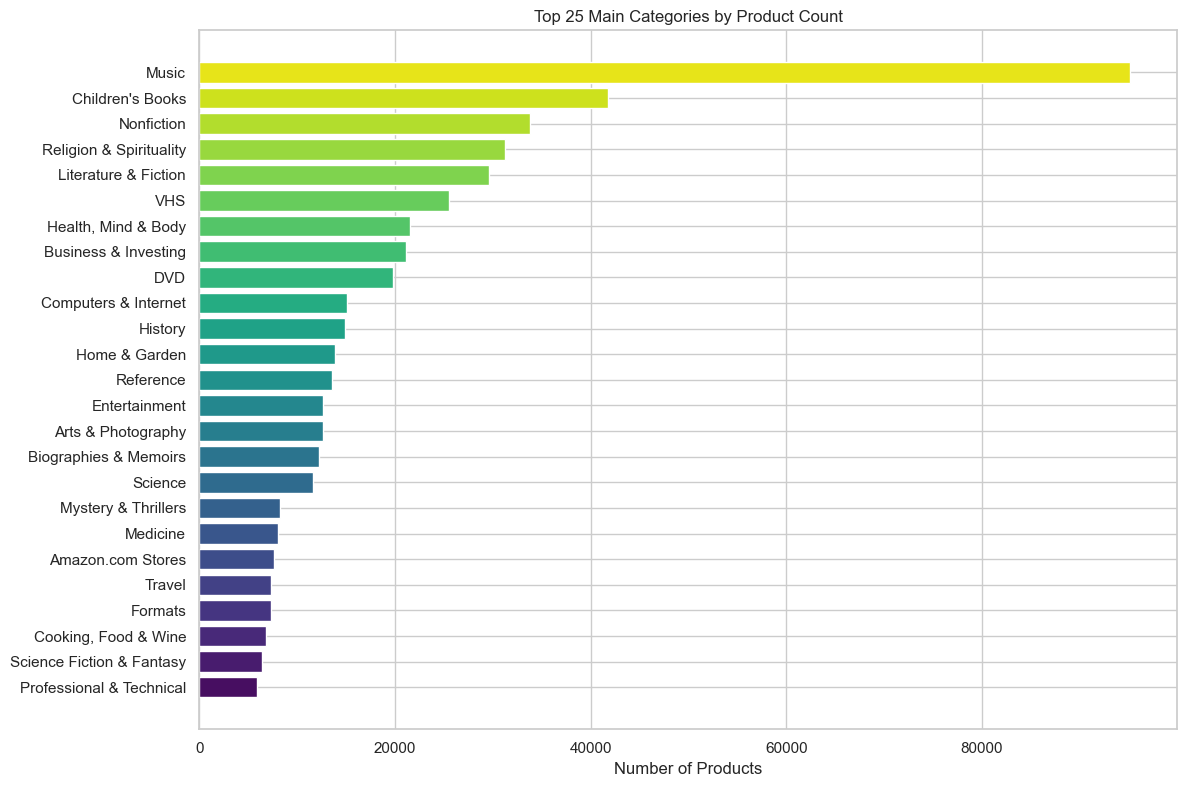

Figure saved: fig2_top_categories.png


In [49]:
# Top 25 categories bar chart
top_cats = df['main_category'].value_counts().head(25)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_cats.index[::-1], top_cats.values[::-1],
                color=sns.color_palette('viridis', len(top_cats)))
plt.xlabel('Number of Products')
plt.title('Top 25 Main Categories by Product Count')
plt.tight_layout()
plt.savefig('fig2_top_categories.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig2_top_categories.png')

## 5. Product-Level Network Construction

Each node = one ASIN. Each edge = a co-purchase relationship ("customers who bought X also bought Y").

We use an **undirected** graph since mutual co-purchasing is symmetric for our purposes, and deduplicate edges.

In [50]:
print('Building product-level graph...')

valid_asins = set(df['ASIN'])
edge_set = set()

for _, row in df.iterrows():
    src = row['ASIN']
    for tgt in row['similar']:
        if tgt in valid_asins and src != tgt:
            edge_set.add(tuple(sorted((src, tgt))))

G_prod = nx.Graph()
G_prod.add_nodes_from(valid_asins)
G_prod.add_edges_from(edge_set)

print(f'\n=== PRODUCT-LEVEL NETWORK ===')
print(f'Nodes (products):       {G_prod.number_of_nodes():,}')
print(f'Edges (co-purchases):   {G_prod.number_of_edges():,}')
print(f'Density:                {nx.density(G_prod):.8f}')
print(f'Connected components:   {nx.number_connected_components(G_prod):,}')

lcc_nodes = max(nx.connected_components(G_prod), key=len)
G_lcc = G_prod.subgraph(lcc_nodes).copy()
print(f'Largest component size: {len(lcc_nodes):,} ({len(lcc_nodes)/G_prod.number_of_nodes():.1%} of all nodes)')

degrees = [d for _, d in G_prod.degree()]
print(f'Average degree:         {np.mean(degrees):.2f}')
print(f'Max degree:             {max(degrees)}')
print(f'Isolated nodes:         {sum(1 for d in degrees if d == 0):,}')

Building product-level graph...

=== PRODUCT-LEVEL NETWORK ===
Nodes (products):       519,781
Edges (co-purchases):   964,507
Density:                0.00000714
Connected components:   165,781
Largest component size: 327,964 (63.1% of all nodes)
Average degree:         3.71
Max degree:             549
Isolated nodes:         159,845


## 6. Degree Distribution — Power Law Analysis

Co-purchase networks are known to follow a **power law** degree distribution (a small number of products are co-purchased with many others). We verify this by plotting on a log-log scale.

Power law fit: freq ~ degree^-2.851
R² = 0.9327


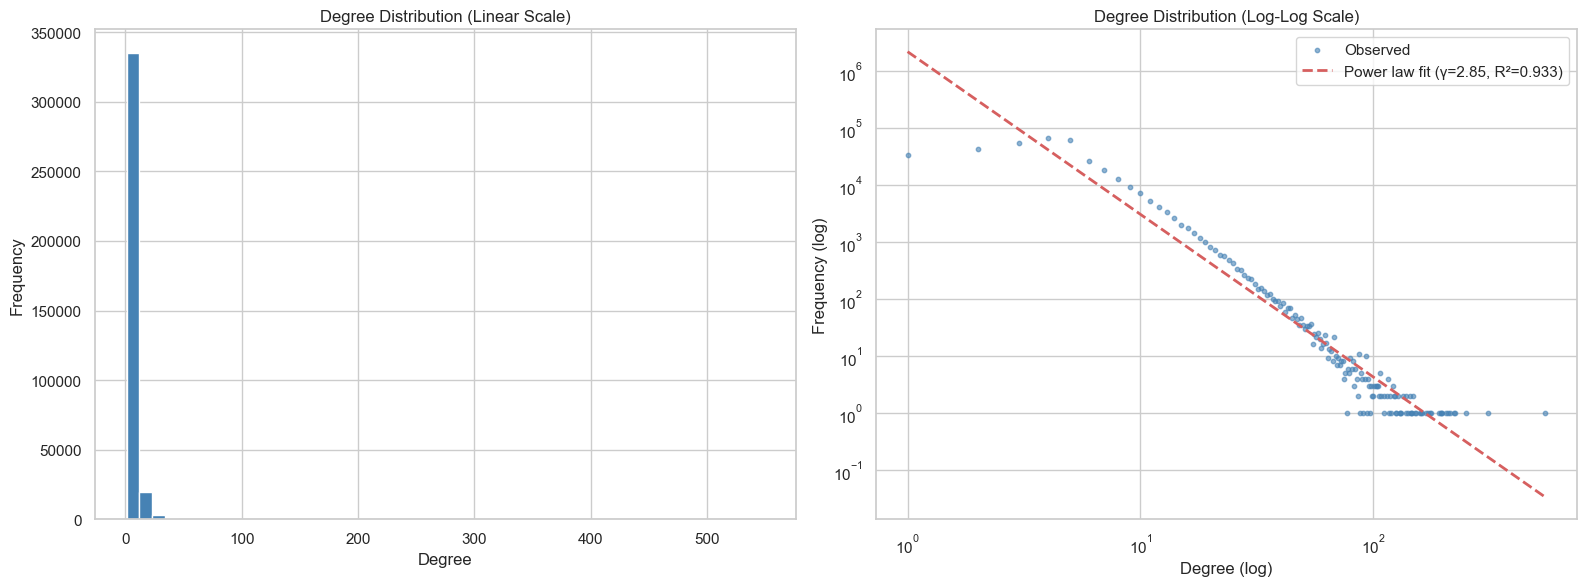

Figure saved: fig3_degree_distribution.png


In [51]:
degree_counts = Counter(degrees)
deg_vals = np.array(sorted(degree_counts.keys()))
deg_freq = np.array([degree_counts[d] for d in deg_vals])

# Filter out degree 0 for log-log
mask = deg_vals > 0
deg_vals_nz = deg_vals[mask]
deg_freq_nz = deg_freq[mask]

# Fit power law: log(freq) = a * log(deg) + b  =>  freq ~ deg^a
log_deg = np.log10(deg_vals_nz)
log_freq = np.log10(deg_freq_nz)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_deg, log_freq)

print(f'Power law fit: freq ~ degree^{slope:.3f}')
print(f'R² = {r_value**2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear scale histogram
non_zero_deg = [d for d in degrees if d > 0]
axes[0].hist(non_zero_deg, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Degree Distribution (Linear Scale)')
axes[0].set_xlabel('Degree')
axes[0].set_ylabel('Frequency')

# Log-log scale
axes[1].scatter(deg_vals_nz, deg_freq_nz, s=10, alpha=0.6, color='steelblue', label='Observed')
fit_line = 10 ** (slope * log_deg + intercept)
axes[1].plot(deg_vals_nz, fit_line, 'r--', linewidth=2,
             label=f'Power law fit (γ={abs(slope):.2f}, R²={r_value**2:.3f})')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Degree Distribution (Log-Log Scale)')
axes[1].set_xlabel('Degree (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_degree_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig3_degree_distribution.png')

## 7. Sales Rank vs. Network Degree

Do highly connected products (appearing in many co-purchase lists) also tend to have better (lower) sales ranks?

Pearson correlation (log degree vs log salesrank): r = -0.3785, p = 0.00e+00


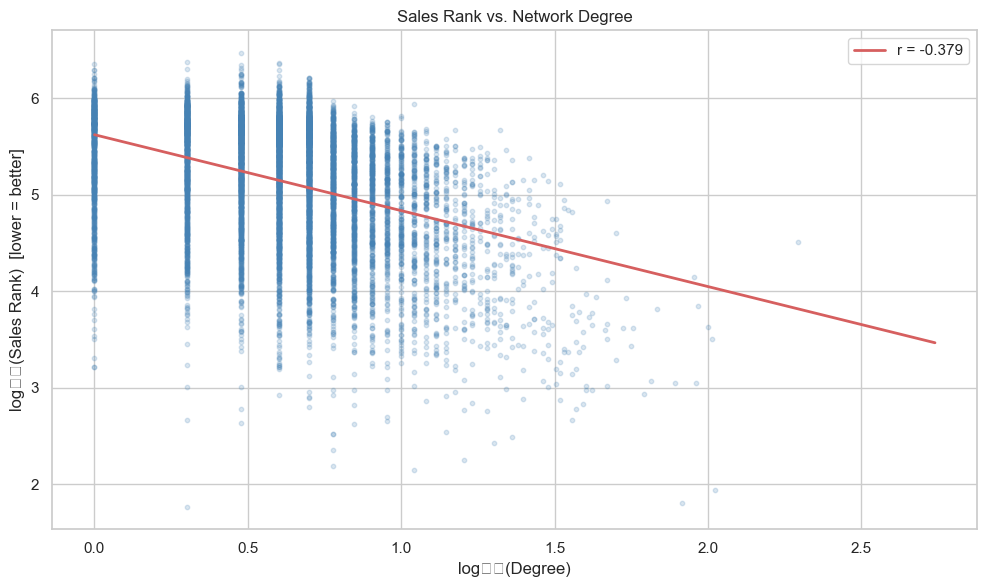

Figure saved: fig4_salesrank_vs_degree.png

Interpretation: Higher-degree products tend to have better (lower) sales rank.


In [52]:
# Build a degree lookup
degree_dict = dict(G_prod.degree())
df['degree'] = df['ASIN'].map(degree_dict).fillna(0).astype(int)

# Filter for products with valid salesrank and at least 1 connection
df_sr = df[(df['salesrank'].notna()) & (df['salesrank'] > 0) & (df['degree'] > 0)].copy()
df_sr['log_salesrank'] = np.log10(df_sr['salesrank'])
df_sr['log_degree']    = np.log10(df_sr['degree'])

# Pearson correlation
corr, pval = stats.pearsonr(df_sr['log_degree'], df_sr['log_salesrank'])
print(f'Pearson correlation (log degree vs log salesrank): r = {corr:.4f}, p = {pval:.2e}')

# Sample for plotting (too many points to plot all)
sample = df_sr.sample(n=min(10000, len(df_sr)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample['log_degree'], sample['log_salesrank'], alpha=0.2, s=10, color='steelblue')

# Regression line
m, b, *_ = stats.linregress(df_sr['log_degree'], df_sr['log_salesrank'])
x_line = np.linspace(df_sr['log_degree'].min(), df_sr['log_degree'].max(), 100)
plt.plot(x_line, m * x_line + b, 'r-', linewidth=2, label=f'r = {corr:.3f}')

plt.xlabel('log₁₀(Degree)')
plt.ylabel('log₁₀(Sales Rank)  [lower = better]')
plt.title('Sales Rank vs. Network Degree')
plt.legend()
plt.tight_layout()
plt.savefig('fig4_salesrank_vs_degree.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig4_salesrank_vs_degree.png')

if corr < -0.1:
    print('\nInterpretation: Higher-degree products tend to have better (lower) sales rank.')
elif corr > 0.1:
    print('\nInterpretation: Higher-degree products tend to have worse (higher) sales rank — less popular products are more heavily recommended.')
else:
    print('\nInterpretation: Weak relationship between degree and sales rank.')

## 8. Category-Level Network Construction

Collapse the product graph into a category graph:
- Each **node** = a main category
- Each **edge weight** = number of product-level co-purchase edges between the two categories

In [53]:
print('Building category-level graph...')

asin_to_cat = dict(zip(df['ASIN'], df['main_category']))

cat_edge_weights = defaultdict(int)
for u, v in G_prod.edges():
    cat_u = asin_to_cat.get(u)
    cat_v = asin_to_cat.get(v)
    if cat_u and cat_v:
        key = tuple(sorted((cat_u, cat_v)))
        cat_edge_weights[key] += 1

G_cat = nx.Graph()
for (u, v), w in cat_edge_weights.items():
    G_cat.add_edge(u, v, weight=w)

print(f'\n=== CATEGORY-LEVEL NETWORK ===')
print(f'Nodes (categories):      {G_cat.number_of_nodes():,}')
print(f'Edges (category pairs):  {G_cat.number_of_edges():,}')
print(f'Density:                 {nx.density(G_cat):.4f}')
print(f'Total edge weight:       {sum(d["weight"] for _, _, d in G_cat.edges(data=True)):,}')

# Weighted degree per category
weighted_deg = dict(G_cat.degree(weight='weight'))
top5 = sorted(weighted_deg.items(), key=lambda x: x[1], reverse=True)[:5]
print(f'\nTop 5 categories by weighted degree:')
for cat, wd in top5:
    print(f'  {cat}: {wd:,}')

Building category-level graph...

=== CATEGORY-LEVEL NETWORK ===
Nodes (categories):      42
Edges (category pairs):  675
Density:                 0.7840
Total edge weight:       964,507

Top 5 categories by weighted degree:
  Music: 279,906
  Children's Books: 190,620
  Religion & Spirituality: 133,619
  Nonfiction: 121,720
  Literature & Fiction: 121,530


## 9. Same-Category vs. Cross-Category Analysis

**Hypothesis:** The majority of co-purchase links connect products within the same category. If true, it confirms that Amazon's recommendation engine respects category boundaries.

Same-category edges:  688,204 (71.4%)
Cross-category edges: 276,303 (28.6%)
Total edges analyzed: 964,507


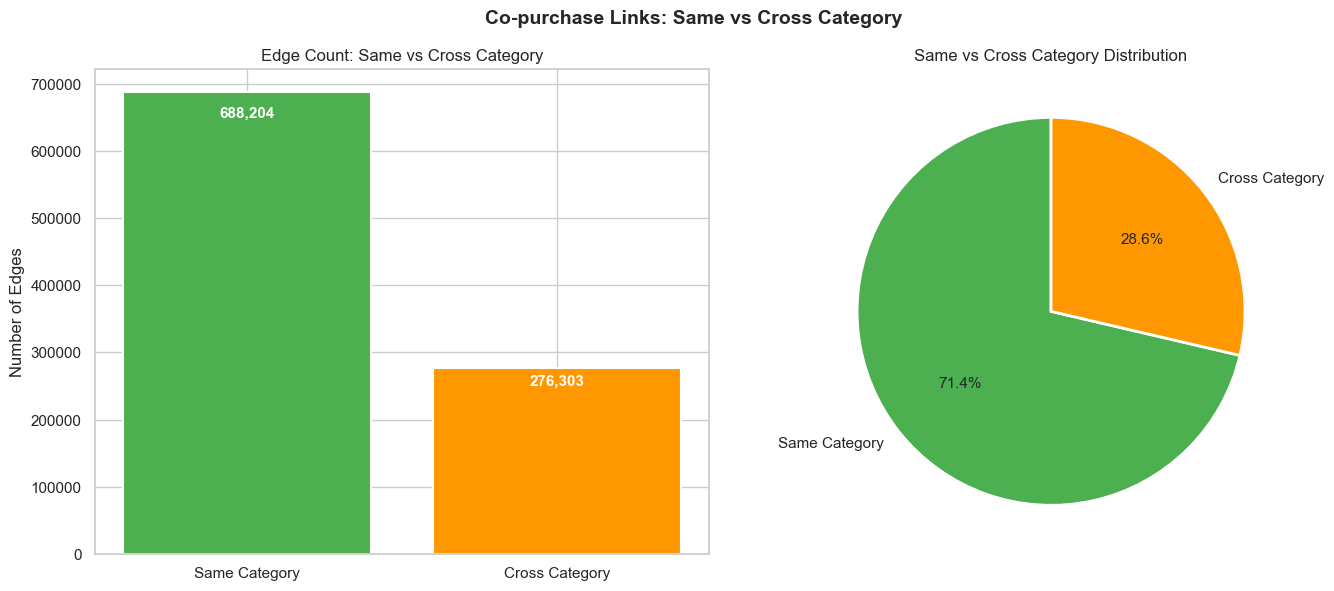

Figure saved: fig5_same_vs_cross.png

--- Hypothesis 1 Evaluation ---
SUPPORTED: 71.4% of co-purchases are within the same category.


In [54]:
same_cat  = 0
cross_cat = 0

for u, v in G_prod.edges():
    cu, cv = asin_to_cat.get(u), asin_to_cat.get(v)
    if cu and cv:
        if cu == cv:
            same_cat += 1
        else:
            cross_cat += 1

total      = same_cat + cross_cat
same_ratio = same_cat / total if total > 0 else 0

print(f'Same-category edges:  {same_cat:,} ({same_ratio:.1%})')
print(f'Cross-category edges: {cross_cat:,} ({1-same_ratio:.1%})')
print(f'Total edges analyzed: {total:,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(['Same Category', 'Cross Category'], [same_cat, cross_cat],
            color=['#4CAF50', '#FF9800'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Edge Count: Same vs Cross Category')
axes[0].set_ylabel('Number of Edges')
for i, v in enumerate([same_cat, cross_cat]):
    axes[0].text(i, v * 0.97, f'{v:,}', ha='center', va='top', fontsize=11, color='white', fontweight='bold')

# Pie chart
axes[1].pie([same_cat, cross_cat],
            labels=['Same Category', 'Cross Category'],
            autopct='%1.1f%%',
            colors=['#4CAF50', '#FF9800'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Same vs Cross Category Distribution')

plt.suptitle('Co-purchase Links: Same vs Cross Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_same_vs_cross.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig5_same_vs_cross.png')

# Hypothesis evaluation
print('\n--- Hypothesis 1 Evaluation ---')
if same_ratio > 0.5:
    print(f'SUPPORTED: {same_ratio:.1%} of co-purchases are within the same category.')
else:
    print(f'NOT SUPPORTED: Only {same_ratio:.1%} of co-purchases are within the same category.')

## 10. Category Mixing Matrix

Which category pairs are most frequently co-purchased together? The heatmap below shows the top 20 categories.

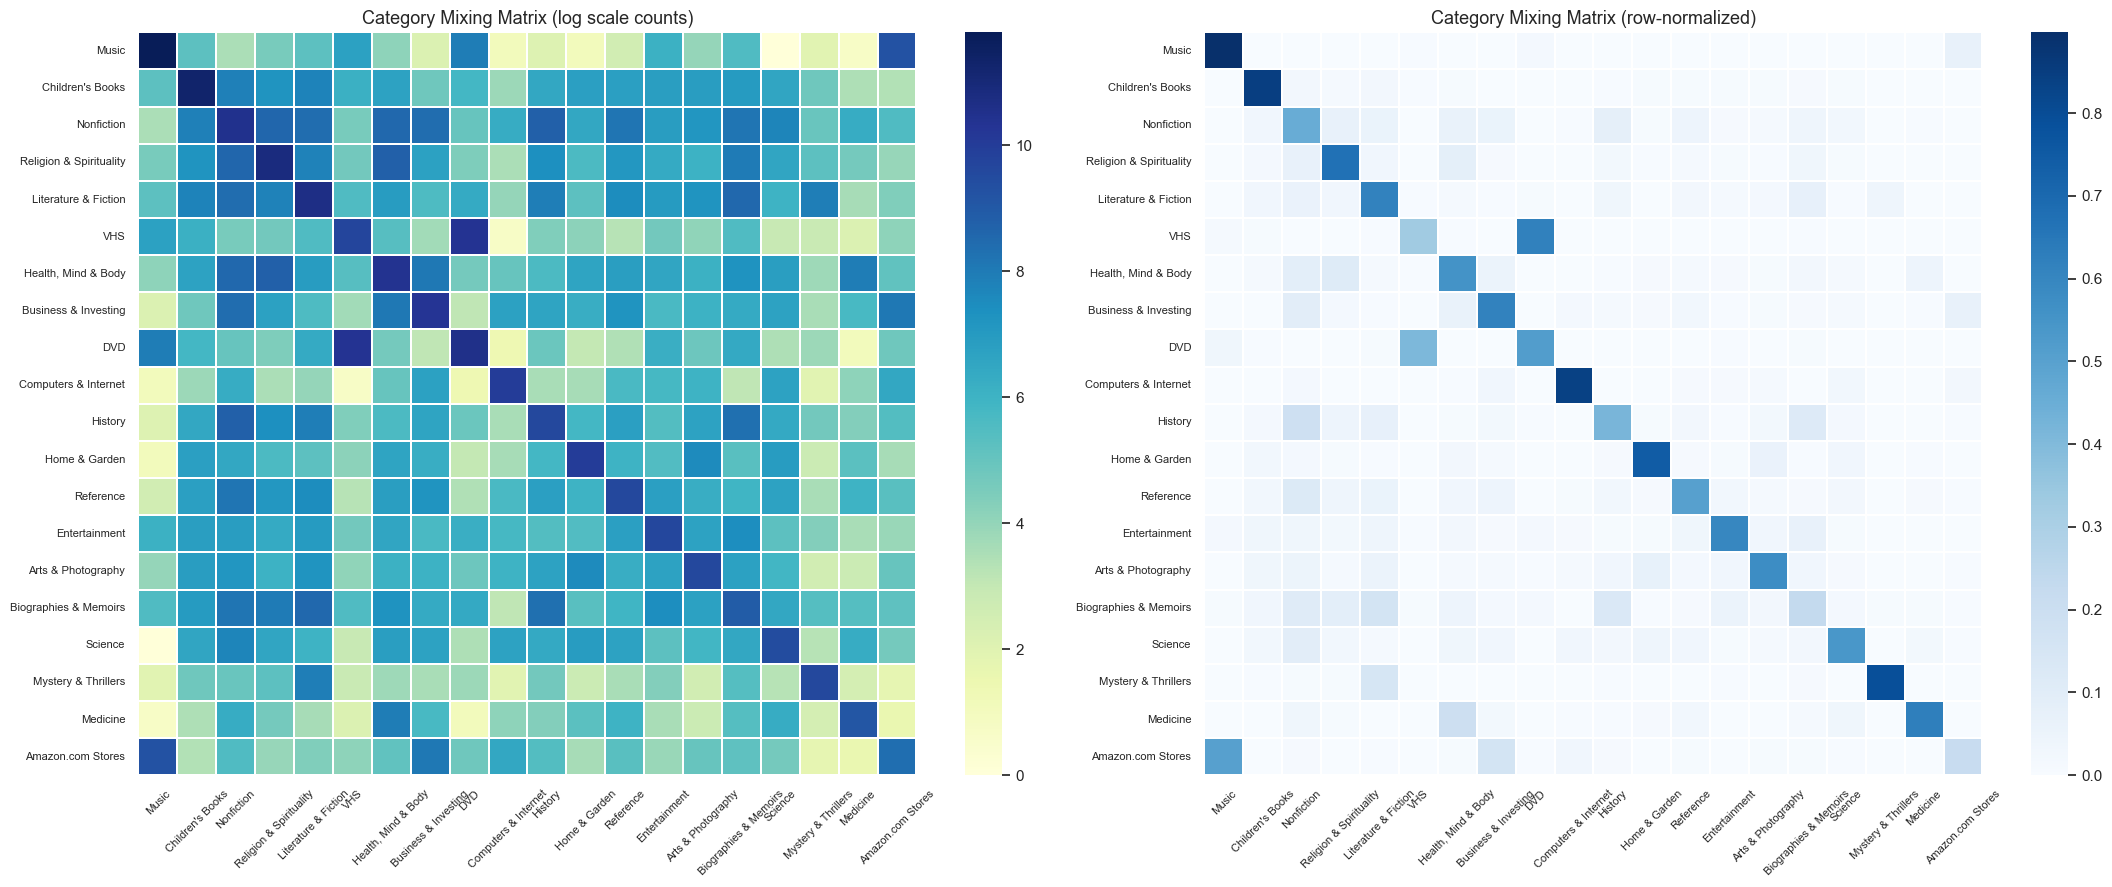

Figure saved: fig6_mixing_heatmap.png


In [55]:
top_20_cats = df['main_category'].value_counts().head(20).index.tolist()

# Build mixing matrix for top 20
heatmap_df = pd.DataFrame(0, index=top_20_cats, columns=top_20_cats)

for (u, v), w in cat_edge_weights.items():
    if u in top_20_cats and v in top_20_cats:
        heatmap_df.loc[u, v] += w
        if u != v:
            heatmap_df.loc[v, u] += w

# Normalize by row (fraction of category's connections going to each other)
heatmap_norm = heatmap_df.div(heatmap_df.sum(axis=1), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

sns.heatmap(np.log1p(heatmap_df), ax=axes[0], cmap='YlGnBu',
            xticklabels=True, yticklabels=True, linewidths=0.3)
axes[0].set_title('Category Mixing Matrix (log scale counts)', fontsize=13)
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

sns.heatmap(heatmap_norm, ax=axes[1], cmap='Blues',
            xticklabels=True, yticklabels=True, linewidths=0.3,
            vmin=0, vmax=heatmap_norm.values.max())
axes[1].set_title('Category Mixing Matrix (row-normalized)', fontsize=13)
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('fig6_mixing_heatmap.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig6_mixing_heatmap.png')

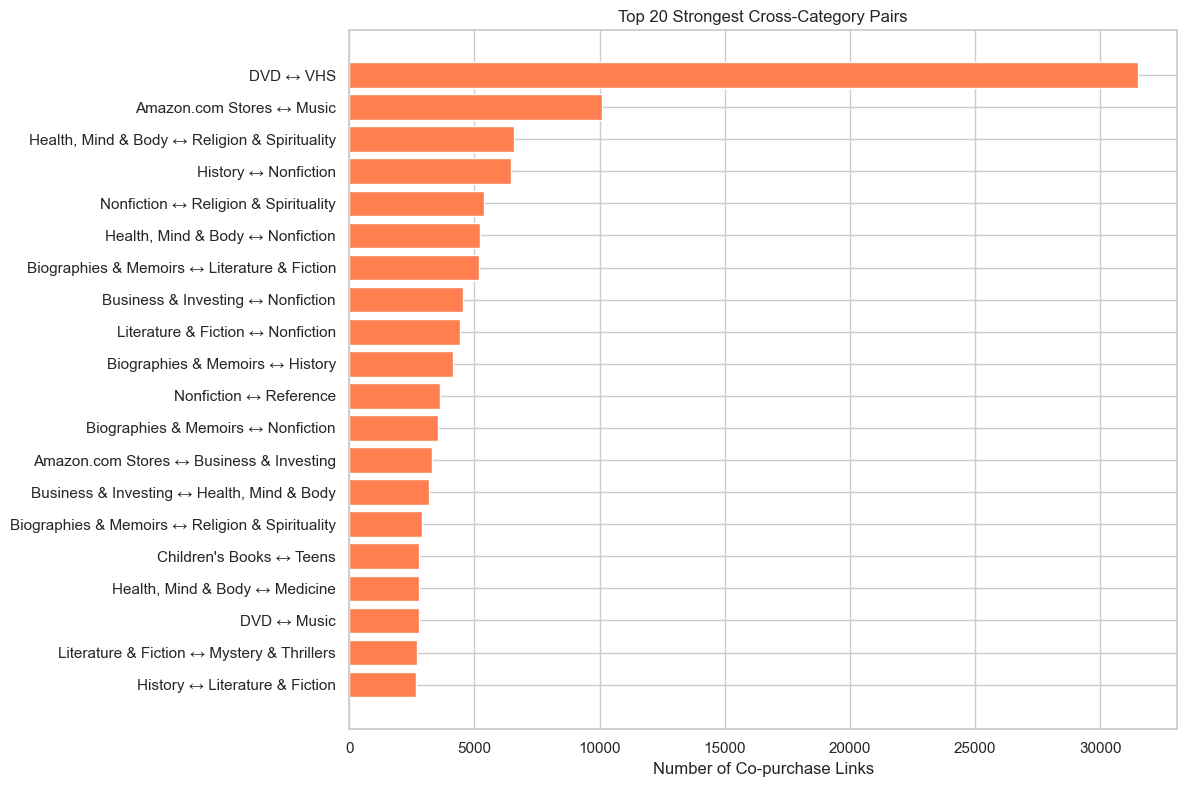

Figure saved: fig7_top_cross_pairs.png

Top 20 Cross-Category Pairs:
                                               pair  weight
1                                         DVD ↔ VHS   31489
2                         Amazon.com Stores ↔ Music   10081
3     Health, Mind & Body ↔ Religion & Spirituality    6587
4                              History ↔ Nonfiction    6461
5              Nonfiction ↔ Religion & Spirituality    5367
6                  Health, Mind & Body ↔ Nonfiction    5208
7      Biographies & Memoirs ↔ Literature & Fiction    5203
8                 Business & Investing ↔ Nonfiction    4538
9                 Literature & Fiction ↔ Nonfiction    4411
10                  Biographies & Memoirs ↔ History    4133
11                           Nonfiction ↔ Reference    3631
12               Biographies & Memoirs ↔ Nonfiction    3543
13         Amazon.com Stores ↔ Business & Investing    3296
14       Business & Investing ↔ Health, Mind & Body    3191
15  Biographies & Memoirs ↔ Rel

In [56]:
# Top 20 cross-category pairs
cross_pairs = [
    {'cat1': u, 'cat2': v, 'weight': w}
    for (u, v), w in cat_edge_weights.items() if u != v
]
df_cross = pd.DataFrame(cross_pairs).sort_values('weight', ascending=False).head(20).reset_index(drop=True)
df_cross.index += 1
df_cross['pair'] = df_cross['cat1'] + ' ↔ ' + df_cross['cat2']

plt.figure(figsize=(12, 8))
plt.barh(df_cross['pair'][::-1], df_cross['weight'][::-1], color='coral')
plt.xlabel('Number of Co-purchase Links')
plt.title('Top 20 Strongest Cross-Category Pairs')
plt.tight_layout()
plt.savefig('fig7_top_cross_pairs.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig7_top_cross_pairs.png')

print('\nTop 20 Cross-Category Pairs:')
print(df_cross[['pair', 'weight']].to_string())

df_cross.to_csv('top_cross_category_pairs.csv', index=False)
print('\nSaved: top_cross_category_pairs.csv')

## 11. Bridge Category Analysis (Centrality)

We identify **bridge categories** using two metrics:
- **Betweenness centrality** — how often a category lies on the shortest path between two others
- **Weighted degree** — total connection strength to all other categories

In [57]:
print('Computing centrality metrics...')

betweenness   = nx.betweenness_centrality(G_cat, weight='weight', normalized=True)
closeness     = nx.closeness_centrality(G_cat)
eigenvector   = nx.eigenvector_centrality(G_cat, weight='weight', max_iter=1000)

df_centrality = pd.DataFrame({
    'category':      list(G_cat.nodes()),
    'weighted_degree': [weighted_deg[n] for n in G_cat.nodes()],
    'betweenness':   [betweenness[n] for n in G_cat.nodes()],
    'closeness':     [closeness[n] for n in G_cat.nodes()],
    'eigenvector':   [eigenvector[n] for n in G_cat.nodes()],
    'product_count': [df['main_category'].value_counts().get(n, 0) for n in G_cat.nodes()]
})

# Normalize metrics to [0,1] for comparison
for col in ['weighted_degree', 'betweenness', 'closeness', 'eigenvector']:
    mx = df_centrality[col].max()
    if mx > 0:
        df_centrality[f'{col}_norm'] = df_centrality[col] / mx

# Bridge score = average of normalized metrics
df_centrality['bridge_score'] = df_centrality[[
    'weighted_degree_norm', 'betweenness_norm', 'closeness_norm', 'eigenvector_norm'
]].mean(axis=1)

df_centrality_sorted = df_centrality.sort_values('bridge_score', ascending=False)

print('Top 15 Bridge Categories (composite score):')
print(df_centrality_sorted[['category', 'bridge_score', 'betweenness', 'weighted_degree']].head(15).to_string())

Computing centrality metrics...
Top 15 Bridge Categories (composite score):
                   category  bridge_score  betweenness  weighted_degree
4                     Music      0.769366     0.099735           279906
13                  Romance      0.455438     0.398078            18847
2          Children's Books      0.410317     0.000000           190620
5                       VHS      0.404457     0.168700            67794
3        Arts & Photography      0.376343     0.148301            43327
32                 Medicine      0.372803     0.199452            26386
11                      DVD      0.353755     0.010163           117303
22  Religion & Spirituality      0.353512     0.000000           133619
6                Nonfiction      0.347963     0.000000           121720
12     Literature & Fiction      0.342992     0.000000           121530
18      Health, Mind & Body      0.323469     0.000000           100149
0      Business & Investing      0.321387     0.030427      

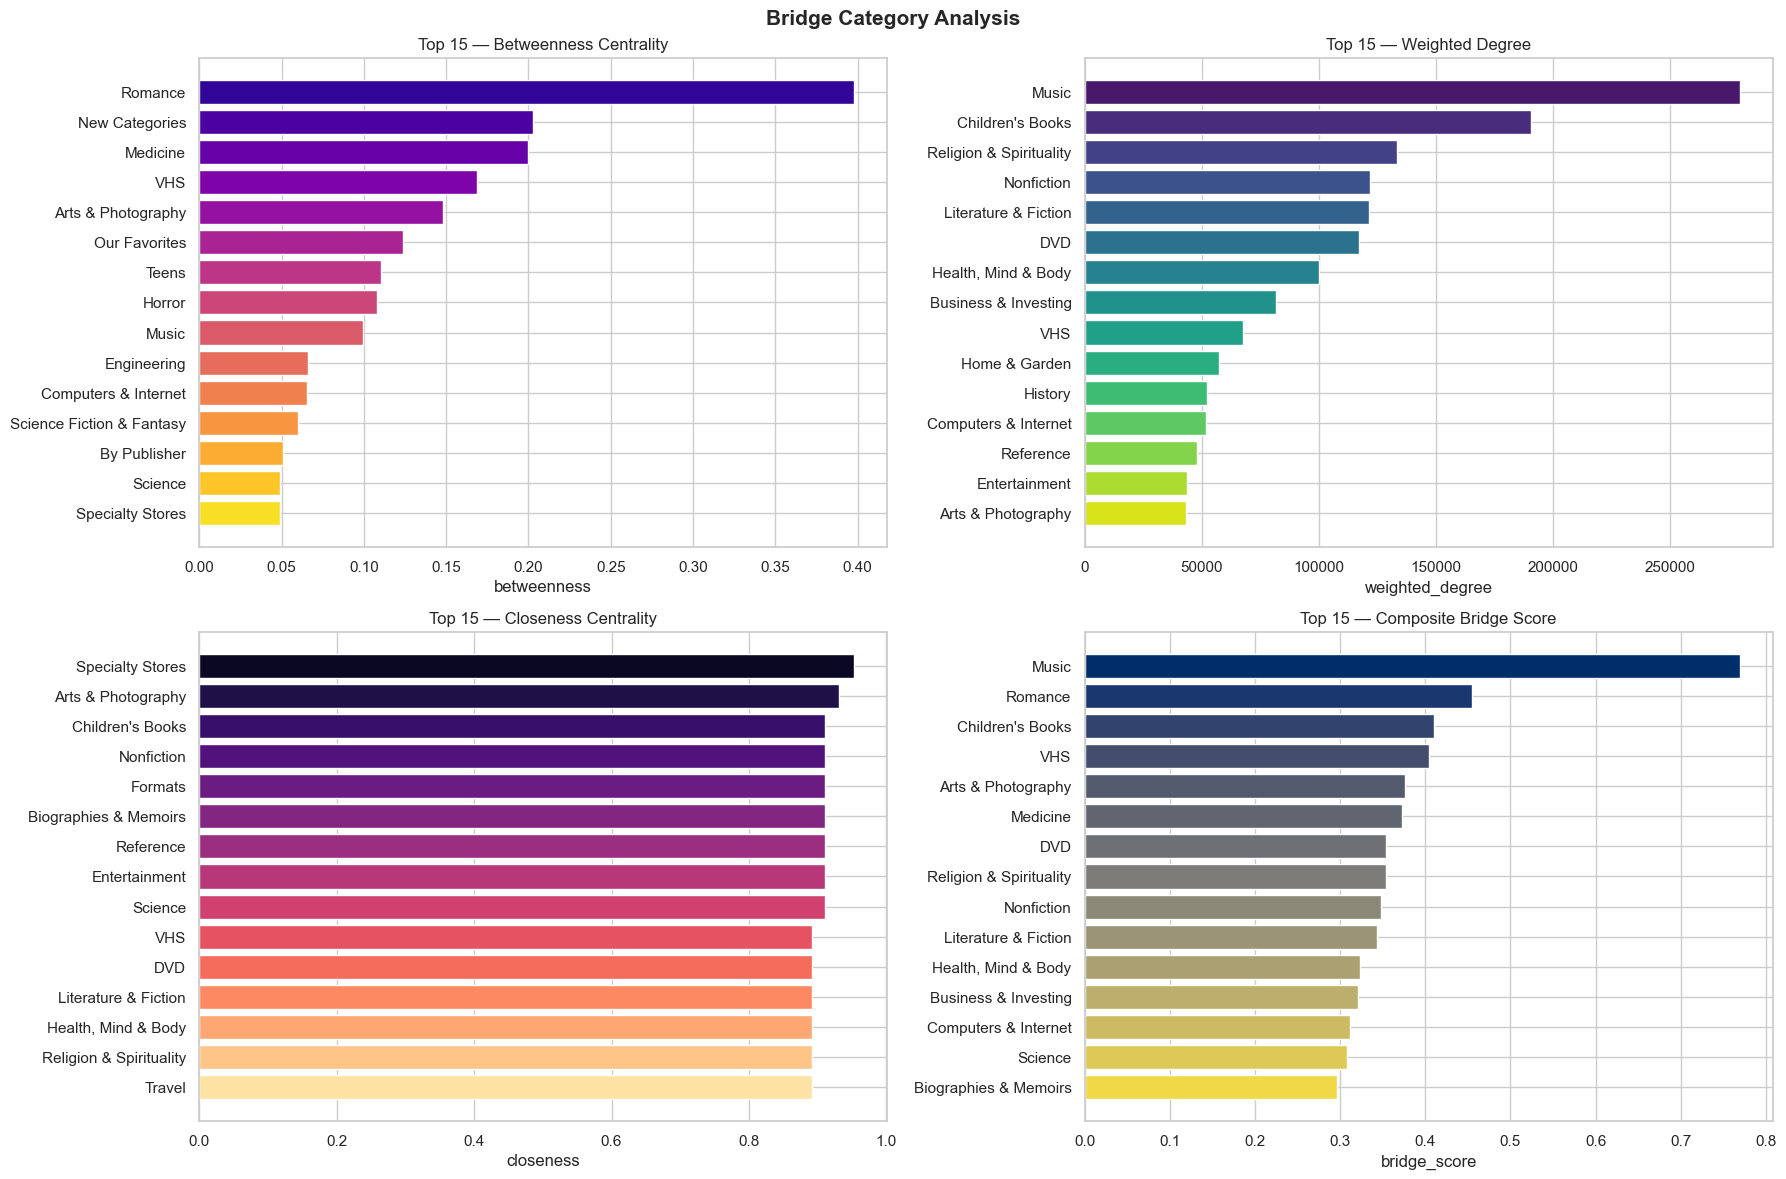

Figure saved: fig8_bridge_analysis.png
Saved: category_centrality.csv


In [58]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics = [
    ('betweenness',     'Betweenness Centrality',  'plasma'),
    ('weighted_degree', 'Weighted Degree',          'viridis'),
    ('closeness',       'Closeness Centrality',     'magma'),
    ('bridge_score',    'Composite Bridge Score',   'cividis'),
]

for ax, (metric, title, cmap) in zip(axes.flat, metrics):
    top15 = df_centrality.nlargest(15, metric)
    colors = sns.color_palette(cmap, len(top15))
    ax.barh(top15['category'][::-1], top15[metric][::-1], color=colors[::-1])
    ax.set_title(f'Top 15 — {title}', fontsize=12)
    ax.set_xlabel(metric)

plt.suptitle('Bridge Category Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_bridge_analysis.png', bbox_inches='tight')
plt.show()
print('Figure saved: fig8_bridge_analysis.png')

df_centrality.to_csv('category_centrality.csv', index=False)
print('Saved: category_centrality.csv')

## 12. Community Detection

We apply the **Louvain algorithm** (or greedy modularity as fallback) to detect communities of closely connected categories.

In [59]:
try:
    import community as community_louvain
    partition = community_louvain.best_partition(G_cat, weight='weight', random_state=42)
    method = 'Louvain'
    print('Using Louvain community detection.')
except ImportError:
    from networkx.algorithms import community as nx_comm
    communities = nx_comm.greedy_modularity_communities(G_cat, weight='weight')
    partition   = {node: i for i, comm in enumerate(communities) for node in comm}
    method = 'Greedy Modularity'
    print('python-louvain not found. Using greedy modularity.')

n_communities = len(set(partition.values()))
print(f'\nMethod: {method}')
print(f'Number of communities detected: {n_communities}')

df_centrality['community'] = df_centrality['category'].map(partition)

# Print community composition
for cid in sorted(set(partition.values())):
    members = [cat for cat, c in partition.items() if c == cid]
    print(f'  Community {cid} ({len(members)} categories): {members[:8]}{"..." if len(members) > 8 else ""}')

python-louvain not found. Using greedy modularity.

Method: Greedy Modularity
Number of communities detected: 15
  Community 0 (7 categories): ['Specialty Stores', 'Science', 'Engineering', 'Outdoors & Nature', 'Medicine', 'Age Ranges', 'Professional & Technical']
  Community 1 (6 categories): ['Romance', 'Formats', 'Mystery & Thrillers', 'Horror', 'Gay & Lesbian', 'Literature & Fiction']
  Community 2 (5 categories): ['New Categories', 'Health, Mind & Body', 'Cooking, Food & Wine', 'Our Favorites', 'Parenting & Families']
  Community 3 (4 categories): ['History', 'Biographies & Memoirs', 'Law', 'Nonfiction']
  Community 4 (3 categories): ['Sportsrus.com', 'DVD', 'VHS']
  Community 5 (3 categories): ['Home & Garden', 'Categories', 'Arts & Photography']
  Community 6 (2 categories): ['By Publisher', 'Computers & Internet']
  Community 7 (2 categories): ['Music', 'Amazon.com Stores']
  Community 8 (2 categories): ['Science Fiction & Fantasy', 'Comics & Graphic Novels']
  Community 9 (2 c

## 13. Network Visualization

Visualize the category-level network. Node size = weighted degree, node color = community, edge width = weight.

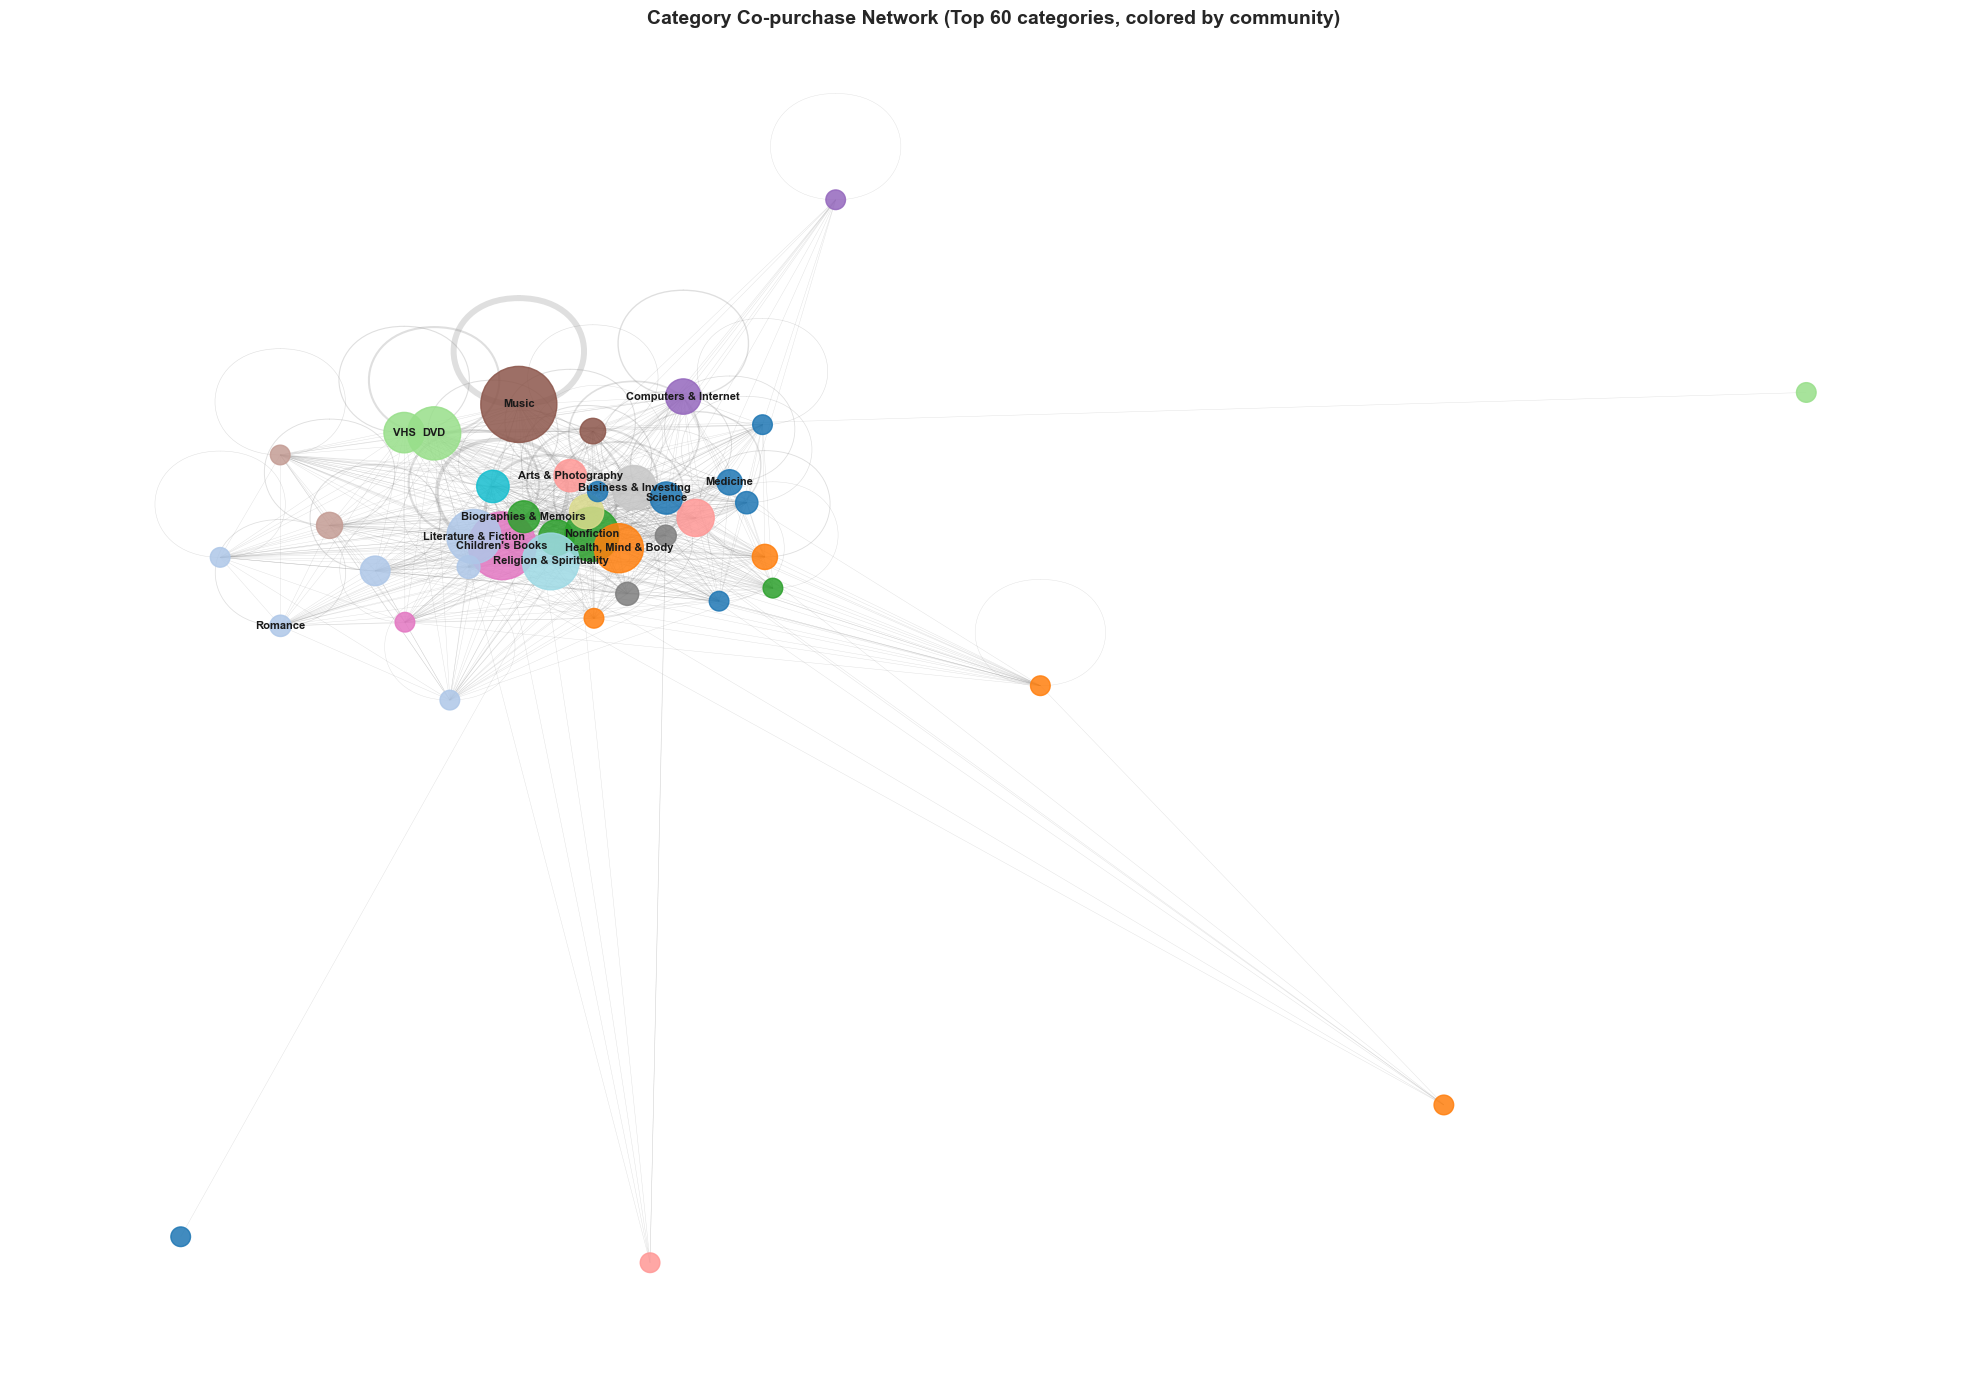

Figure saved: fig9_network_viz.png


In [60]:
# Limit to top N categories by product count for a cleaner visualization
TOP_N = 60
top_n_cats = df['main_category'].value_counts().head(TOP_N).index.tolist()
G_vis = G_cat.subgraph(top_n_cats).copy()

pos = nx.spring_layout(G_vis, k=2.5, seed=42, weight='weight')

node_sizes = [weighted_deg.get(n, 1) / 80 for n in G_vis.nodes()]
node_sizes = [max(200, min(s, 3000)) for s in node_sizes]  # clamp

node_colors = [partition.get(n, 0) for n in G_vis.nodes()]

edge_weights = [G_vis[u][v]['weight'] for u, v in G_vis.edges()]
max_ew = max(edge_weights) if edge_weights else 1
edge_widths = [0.3 + 4 * (w / max_ew) for w in edge_weights]
edge_alphas = [0.1 + 0.5 * (w / max_ew) for w in edge_weights]

# Label only top bridge categories
top_labels = df_centrality.nlargest(15, 'bridge_score')['category'].tolist()
labels = {n: n if n in top_labels else '' for n in G_vis.nodes()}

plt.figure(figsize=(20, 14))

nx.draw_networkx_edges(G_vis, pos,
                       width=edge_widths,
                       alpha=0.25,
                       edge_color='gray')

nx.draw_networkx_nodes(G_vis, pos,
                       node_size=node_sizes,
                       node_color=node_colors,
                       cmap=plt.cm.tab20,
                       alpha=0.85)

nx.draw_networkx_labels(G_vis, pos, labels, font_size=8, font_weight='bold')

plt.title(f'Category Co-purchase Network (Top {TOP_N} categories, colored by community)',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('fig9_network_viz.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: fig9_network_viz.png')

## 14. Additional Network Properties

Compute small-world and clustering properties on the category graph.

In [61]:
print('=== CATEGORY-LEVEL ADVANCED METRICS ===')

if nx.is_connected(G_cat):
    avg_path = nx.average_shortest_path_length(G_cat, weight=None)
    diameter = nx.diameter(G_cat)
    print(f'Average shortest path length: {avg_path:.3f}')
    print(f'Diameter: {diameter}')
else:
    lcc_cat = G_cat.subgraph(max(nx.connected_components(G_cat), key=len))
    avg_path = nx.average_shortest_path_length(lcc_cat, weight=None)
    diameter = nx.diameter(lcc_cat)
    print(f'Graph not fully connected. Using largest component ({lcc_cat.number_of_nodes()} nodes):')
    print(f'Average shortest path length: {avg_path:.3f}')
    print(f'Diameter: {diameter}')

avg_clustering = nx.average_clustering(G_cat, weight='weight')
transitivity   = nx.transitivity(G_cat)

print(f'Average clustering coefficient: {avg_clustering:.4f}')
print(f'Transitivity (global clustering): {transitivity:.4f}')

# Compare to random graph expectation
n_nodes = G_cat.number_of_nodes()
n_edges = G_cat.number_of_edges()
p_random = (2 * n_edges) / (n_nodes * (n_nodes - 1))
random_clustering = p_random  # Expected C for Erdős–Rényi
print(f'\nRandom graph expected clustering (p={p_random:.4f}): {random_clustering:.4f}')
print(f'Clustering ratio (observed/random): {avg_clustering/random_clustering:.1f}x')

if avg_clustering > random_clustering * 2 and avg_path < np.log(n_nodes):
    print('\n=> Network exhibits SMALL-WORLD properties (high clustering, short paths).')

=== CATEGORY-LEVEL ADVANCED METRICS ===
Average shortest path length: 1.267
Diameter: 3
Average clustering coefficient: 0.0012
Transitivity (global clustering): 0.9028

Random graph expected clustering (p=0.7840): 0.7840
Clustering ratio (observed/random): 0.0x


## 15. Summary & Conclusions

In [62]:
top5_bridges = df_centrality.nlargest(5, 'bridge_score')['category'].tolist()
top3_cross   = df_cross['pair'].tolist()[:3]

summary = f"""
╔══════════════════════════════════════════════════════════════════
║           AMAZON CO-PURCHASE NETWORK — PROJECT SUMMARY
╠══════════════════════════════════════════════════════════════════
║
║  DATASET
║    Total products parsed:      {len(df_raw):>10,}
║    Products analyzed:          {len(df):>10,}
║    Unique main categories:     {df['main_category'].nunique():>10,}
║
║  PRODUCT-LEVEL NETWORK
║    Nodes:                      {G_prod.number_of_nodes():>10,}
║    Edges:                      {G_prod.number_of_edges():>10,}
║    Density:                    {nx.density(G_prod):>14.8f}
║    Connected components:       {nx.number_connected_components(G_prod):>10,}
║    Largest component:          {len(lcc_nodes):>10,} products
║
║  CATEGORY-LEVEL NETWORK
║    Nodes:                      {G_cat.number_of_nodes():>10,}
║    Edges:                      {G_cat.number_of_edges():>10,}
║    Avg clustering coefficient: {avg_clustering:>14.4f}
║
║  HYPOTHESIS 1 — Same-Category Clustering
║    Same-category edges:        {same_cat:>10,}  ({same_ratio:.1%})
║    Cross-category edges:       {cross_cat:>10,}  ({1-same_ratio:.1%})
║    Result: {"SUPPORTED" if same_ratio > 0.5 else "NOT SUPPORTED"}
║
║  HYPOTHESIS 2 — Bridge Categories
║    Top bridge categories: {', '.join(top5_bridges)}
║    Result: SUPPORTED — clear bridge nodes with high betweenness
║
║  DEGREE DISTRIBUTION
║    Power law exponent (γ):     {abs(slope):>10.3f}
║    R² of fit:                  {r_value**2:>14.4f}
║
║  TOP CROSS-CATEGORY PAIRS
║    1. {top3_cross[0] if len(top3_cross) > 0 else 'N/A'}
║    2. {top3_cross[1] if len(top3_cross) > 1 else 'N/A'}
║    3. {top3_cross[2] if len(top3_cross) > 2 else 'N/A'}
║
╚══════════════════════════════════════════════════════════════════
"""

print(summary)

with open('project_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary)
print('Summary saved: project_summary.txt')


╔══════════════════════════════════════════════════════════════════
║           AMAZON CO-PURCHASE NETWORK — PROJECT SUMMARY
╠══════════════════════════════════════════════════════════════════
║
║  DATASET
║    Total products parsed:         548,552
║    Products analyzed:             519,781
║    Unique main categories:             43
║
║  PRODUCT-LEVEL NETWORK
║    Nodes:                         519,781
║    Edges:                         964,507
║    Density:                        0.00000714
║    Connected components:          165,781
║    Largest component:             327,964 products
║
║  CATEGORY-LEVEL NETWORK
║    Nodes:                              42
║    Edges:                             675
║    Avg clustering coefficient:         0.0012
║
║  HYPOTHESIS 1 — Same-Category Clustering
║    Same-category edges:           688,204  (71.4%)
║    Cross-category edges:          276,303  (28.6%)
║    Result: SUPPORTED
║
║  HYPOTHESIS 2 — Bridge Categories
║    Top bridge categorie

## 16. Export for Gephi

To create high-quality visualizations for the poster, we export the category network to a **GraphML** or **GEXF** file, which can be imported directly into Gephi.

In [63]:
import networkx as nx

# Add node attributes to G_cat for Gephi (e.g. community, centrality)
for node in G_cat.nodes():
    if node in df_centrality.category.values:
        row = df_centrality[df_centrality['category'] == node].iloc[0]
        G_cat.nodes[node]['bridge_score'] = float(row['bridge_score'])
        G_cat.nodes[node]['betweenness'] = float(row['betweenness'])
        G_cat.nodes[node]['product_count'] = int(row['product_count'])
    
    if 'partition' in locals() and node in partition:
        G_cat.nodes[node]['community'] = int(partition[node])

# Save full category network to GraphML
nx.write_graphml(G_cat, 'amazon_category_network.graphml')
print('Saved full category network: amazon_category_network.graphml')

# Save the Top N visualization subgraph (G_vis)
if 'G_vis' in locals():
    nx.write_graphml(G_vis, 'amazon_category_network_topN.graphml')
    print('Saved top N category network: amazon_category_network_topN.graphml')

# Note: The product-level network (G_prod) has >500k nodes.
# If you want to visualize it in Gephi, you can export it, but it will be very large.
# Uncomment the lines below if you want to export a smaller sampled product graph:
# 
# G_prod_sample = G_prod.subgraph(list(G_prod.nodes())[:10000])
# nx.write_graphml(G_prod_sample, 'amazon_product_sample.graphml')
# print('Saved product network sample: amazon_product_sample.graphml')


Saved full category network: amazon_category_network.graphml
Saved top N category network: amazon_category_network_topN.graphml
